In [1]:
from obspy import *
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np
import datetime
from obspy.signal.cross_correlation import correlation_detector

This is the calving event that Riley caught on camera. 

In [2]:
#Mar Piedmont Glacier Calving Event
#%run palmer_picker.py 2026-03-03T15:11 2026-03-03T15:11:30

#st.spectrogram()
#st.plot(equal_scale=False)
#for item in st:
    #item.write(f"{item.stats.station+ st[0].stats.starttime.strftime('%m-%dT%H:%M')}.mseed", format="MSEED")

In [28]:
%run palmer_picker.py 2026-03-03T00:00 2026-03-10T00:00
#st.plot()
#len(trig_times)

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x39c3a2790>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x39c3a8450>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-10T00%3A00%3A00.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-02T23%3A59%3A47.750000&endtime=2026-03-10T00%3A00%3A03.850000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-10T00%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.


NameError: name 'Fals' is not defined

In [23]:
def stat_plotter(df):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()

    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'Palmer Events') #local time
    ax.set_xlabel('Hours in Local Time (UTC-3)')
    ax.set_ylabel('Number of Triggers')
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    
    
    #pick_5 = daily_utc/(24*60) #event time put y-axis in pick per 5 ish min, or pick per minute
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'unfiltered') #pick per hour
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    #ax.set_ylim(5,15)
    ax.set_title("Average Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per Hour')
    ax.legend()
    
    fig.tight_layout(pad=3.0) 

    fig.add_gridspec(4, 4, wspace=0, hspace=0)
   
    #interevent time plot
   
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'unfiltered') 
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()

    #ax = df.groupby(pd.Grouper(key='onset', freq='h')).size().plot(color = 'blue')
    ax = hourly_counts.plot(color = 'red', label = 'filtered')
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per hour')
    #ax.set_ylim(0, 25)
    fig.tight_layout(pad=3.0) 
    fig.legend()
    fig.add_gridspec(8, 8, wspace=0, hspace=0)

    return None
    

In [25]:
trig_times[-1]

[2026-03-03T05:52:19.900000Z, 2026-03-03T05:52:20.850000Z]

In [21]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour

#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/Palmer')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)

#Interevent spacing
trigger_df['interevent_time'] = trigger_df['onset'].shift(-1) - trigger_df['offset']
trigger_df['interevent_time'] = trigger_df['interevent_time'].mask(trigger_df['interevent_time'] < pd.to_timedelta(100, unit='s'))
#Hourly and Daily counts
trigger_df["hourly_counts"] = trigger_df.groupby(trigger_df['local'].dt.hour).size() #in local time
hour_utc = trigger_df.groupby(trigger_df['onset'].dt.hour).size() #UTC
daily_counts = trigger_df.groupby(trigger_df['local'].dt.day).size() #in local time
daily_utc = trigger_df.groupby(trigger_df['onset'].dt.day).size()
#trigger_df['amplitude m'] = pd.DataFrame(peak_amps) #amplitude - displacement in meters

#trigger_df

,onset,offset,month,day,hour_UTC,local,hour_local,day_local,interevent_time,hourly_counts
0,2026-03-03 00:06:41.600,2026-03-03 00:06:42.550,3,3,0,2026-03-02 21:06:41.600000-03:00,21,2,0 days 00:09:10.250000,9.0
1,2026-03-03 00:15:52.800,2026-03-03 00:15:55.100,3,3,0,2026-03-02 21:15:52.800000-03:00,21,2,0 days 00:20:55.650000,7.0
2,2026-03-03 00:36:50.750,2026-03-03 00:36:51.550,3,3,0,2026-03-02 21:36:50.750000-03:00,21,2,0 days 00:03:11.100000,10.0
3,2026-03-03 00:40:02.650,2026-03-03 00:40:05.200,3,3,0,2026-03-02 21:40:02.650000-03:00,21,2,0 days 00:02:28.300000,NaN
4,2026-03-03 00:42:33.500,2026-03-03 00:42:34.200,3,3,0,2026-03-02 21:42:33.500000-03:00,21,2,NaT,NaN
5,2026-03-03 00:43:30.850,2026-03-03 00:43:33.450,3,3,0,2026-03-02 21:43:30.850000-03:00,21,2,0 days 00:02:26.600000,NaN
6,2026-03-03 00:46:00.050,2026-03-03 00:46:01.250,3,3,0,2026-03-02 21:46:00.050000-03:00,21,2,0 days 00:12:45.350000,NaN
7,2026-03-03 00:58:46.600,2026-03-03 00:58:48.150,3,3,0,2026-03-02 21:58:46.600000-03:00,21,2,0 days 00:10:34.700000,NaN
8,2026-03-03 01:09:22.850,2026-03-03 01:09:23.950,3,3,1,2026-03-02 22:09:22.850000-03:00,22,2,0 days 00:11:36.100000,NaN
9,2026-03-03 01:21:00.050,2026-03-03 01:21:00.800,3,3,1,2026-03-02 22:21:00.050000-03:00,22,2,0 days 00:02:33.150000,NaN


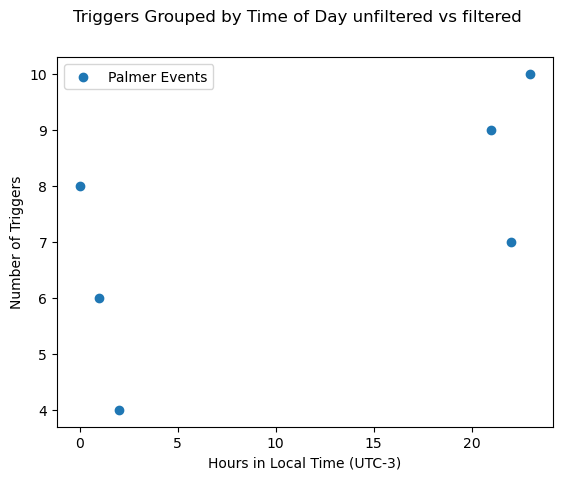

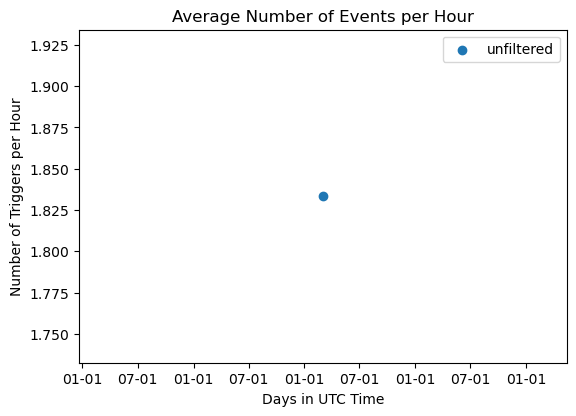

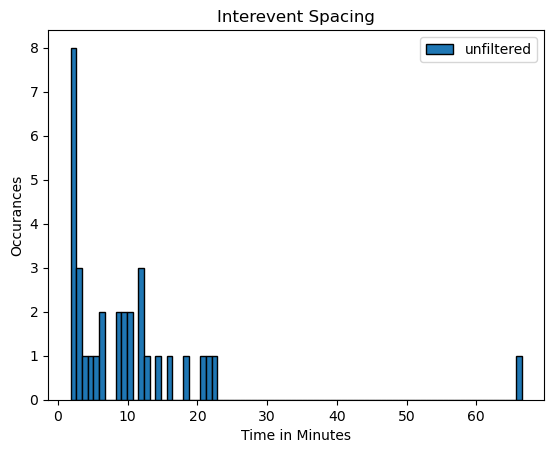

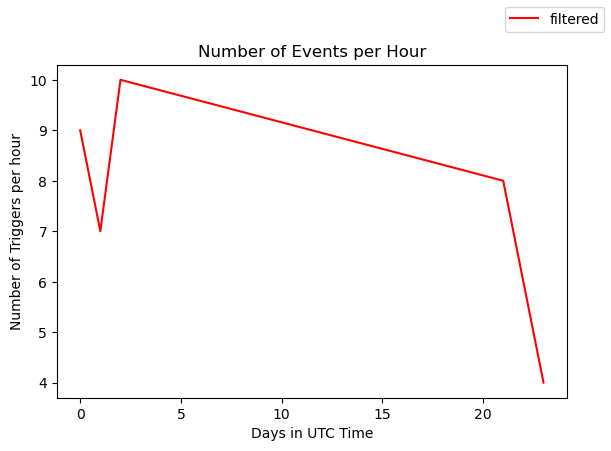

In [24]:
# COMPARING THE FILTERED VS. UNFILTERED TRIGGER PICKS. FILTERING BY TIME INBETWEEN TRIGGERS
#adding in the additional filter by amplitude reduces the likelihood of double picking!
stat_plotter(trigger_df)


## Preparing for Template Matching ##

/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (10) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


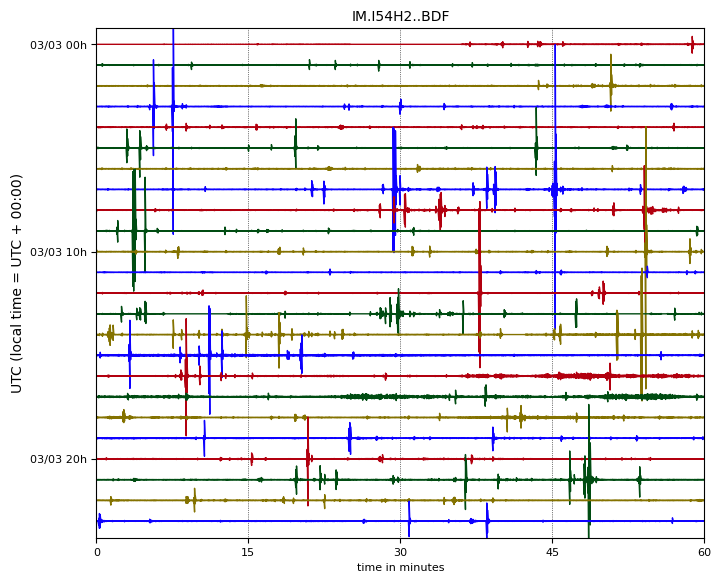

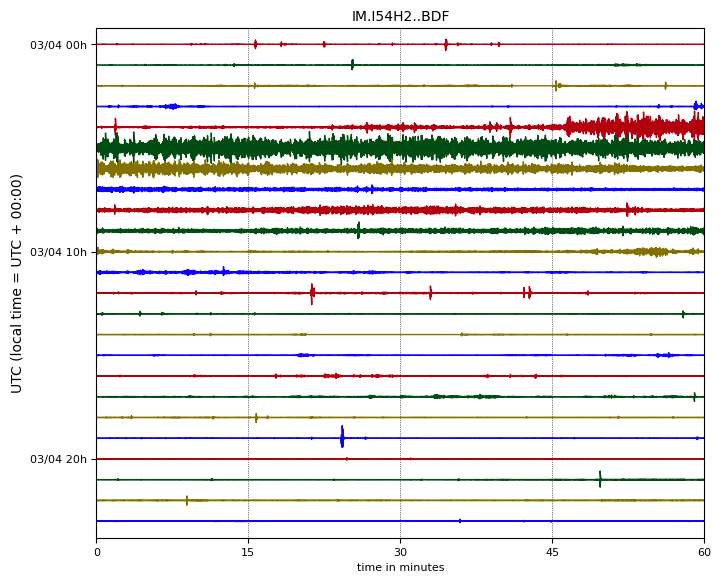

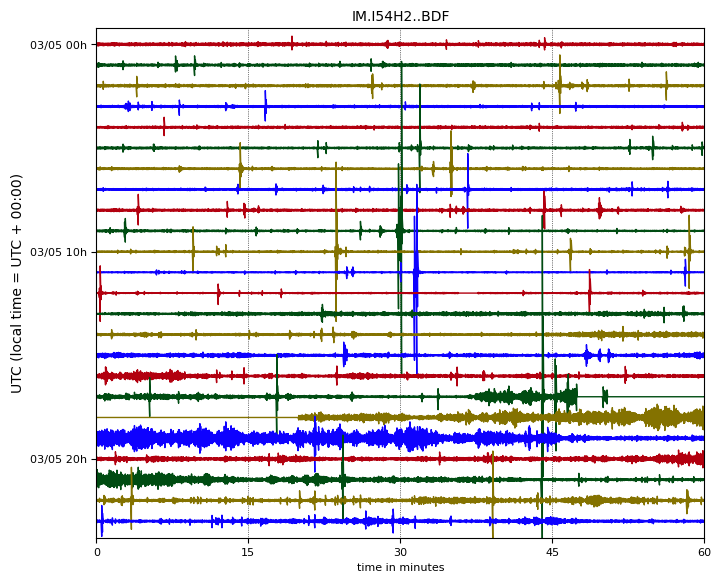

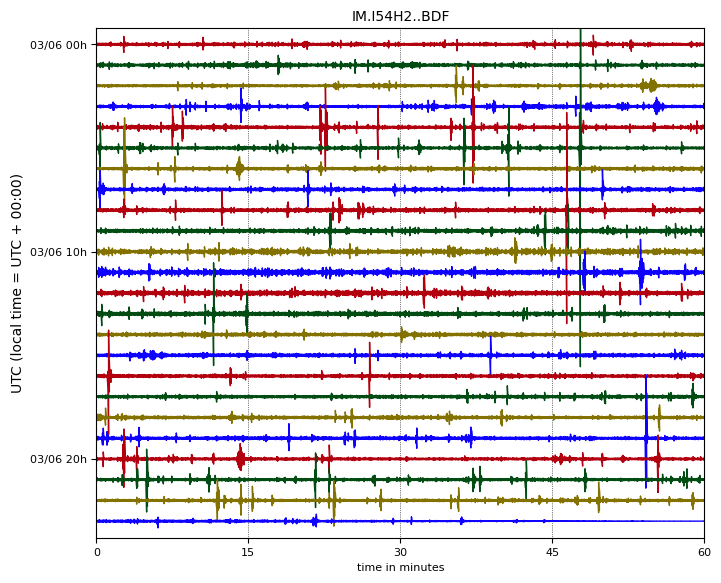

In [7]:
#Dayplots
st.filter("bandpass", freqmin=2, freqmax=10)
for tr in st:
    for i in range(len(pd.to_datetime(trigger_df['onset']).dt.date.unique())):
        start_time = st[0].stats.starttime
        day_start = start_time + (i * 86400)
        day_end = day_start + 86400
        daily_st = st.slice(day_start, day_end)
        local_offset = +13 * 3600
        daily_st.plot(type='dayplot', interval=60, tick_format='%m/%d %Hh', 
                      offset=local_offset,
                      show_y_UTC_label=True  )# interval is minutes per line


Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x36fba2a50>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x36fc282d0>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T03%3A00%3A00.000000&endtime=2026-03-03T04%3A00%3A00.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-03T02%3A59%3A57.350000&endtime=2026-03-03T04%3A00%3A02.150000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-03-03T03%3A00%3A00.000000&endtime=2026-03-03T04%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.


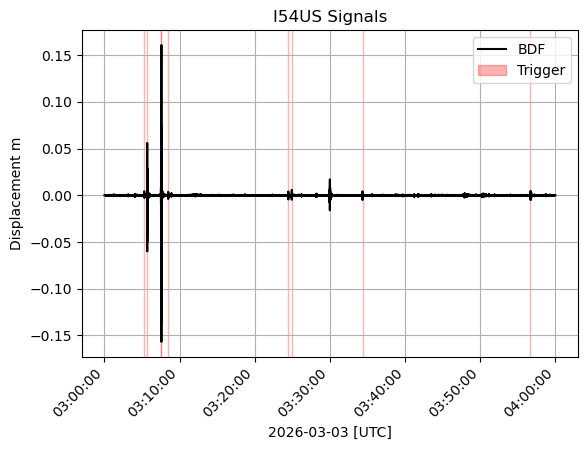

9


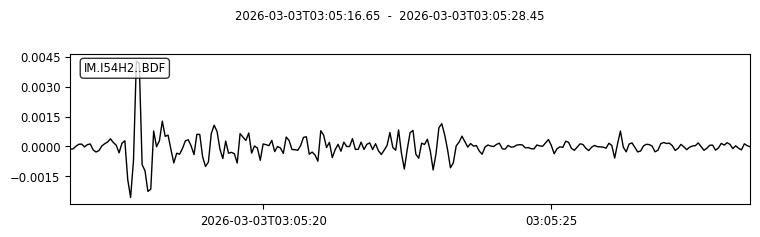

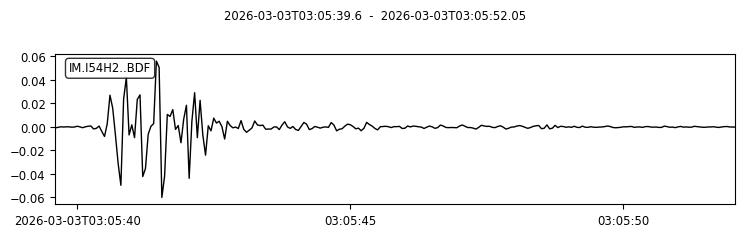

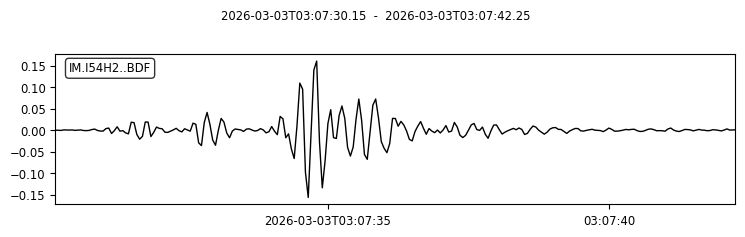

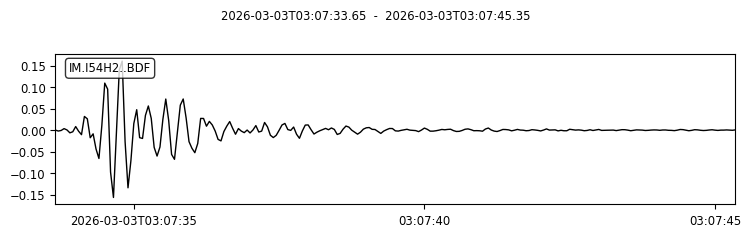

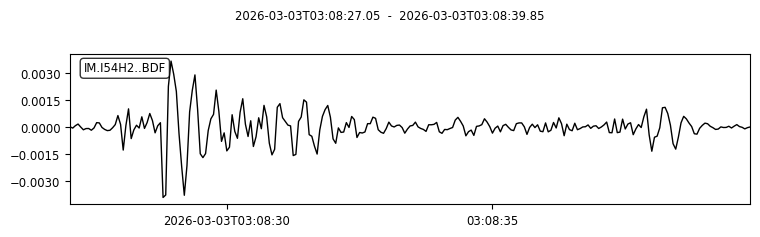

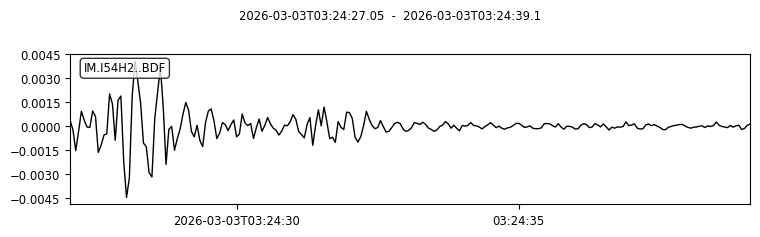

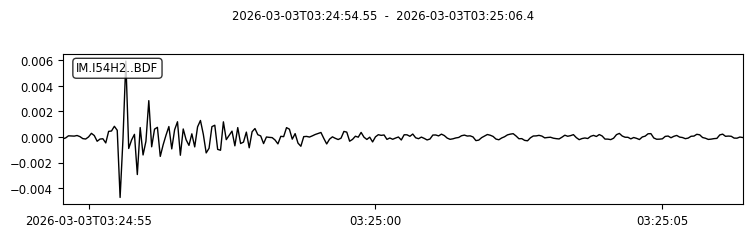

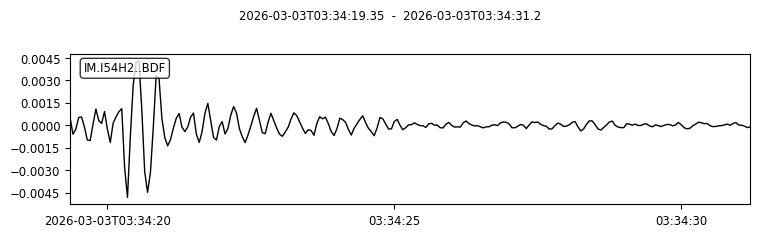

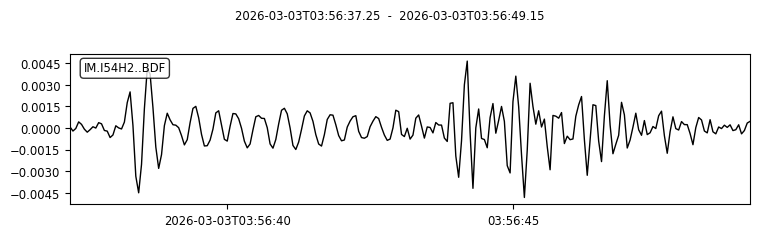

In [8]:
%run palmer_picker.py 2026-03-03T03:00 2026-03-03T04:00:00
print(len(trig_times))
starttime = st[0].stats.starttime
i = 1

while starttime < st[0].stats.endtime:
    endtime = starttime + 3600
    
    # Cap the endtime to the stream's end to prevent out-of-bounds slicing
    if endtime > st[0].stats.endtime:
        endtime = st[0].stats.endtime
        
    hr = st.slice(starttime, endtime)
    
    # Ensure hr is not empty before processing
    if len(hr) > 0 and len(hr[0].data) > 0:
        d, s = correlation_detector(hr, Stream(sliced_wvf[0]), 0.5, 10)
    starttime = endtime
    i += 1
for s in sliced_wvf:
    s.plot()

In [9]:
st

1 Trace(s) in Stream:
IM.I54H2..BDF | 2026-03-03T03:00:00.000000Z - 2026-03-03T04:00:00.000000Z | 20.0 Hz, 72001 samples

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x31c007090>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x177f601d0>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-02T23%3A59%3A47.750000&endtime=2026-03-03T06%3A00%3A01.000000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.


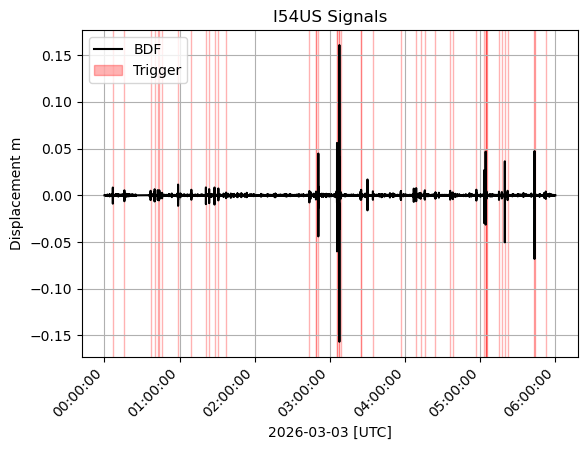

44 11


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/signal/cross_correlation.py:291: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(norm, out=norm)


In [10]:
%run palmer_picker.py 2026-03-03T00:00 2026-03-03T06:00:00
template1 = st.slice(UTCDateTime('2026-03-03T03:07:30.15'), UTCDateTime('2026-03-03T03:07:42.25'))
d, s = correlation_detector(st, template1, 0.5, 10)
print(len(trig_times),len(d))